# Phase 8: Forecasting Baseline

Store-product-week demand forecasting baseline with naive and feature-based models.

## Decision Flow

1. Use time-ordered split to mimic forward forecasting.
2. Build naive baselines first (`lag_1w`, `lag_4w`, and blended naive).
3. Exclude leakage-prone current-week outcome fields.
4. Train a feature-based Random Forest regressor using only approved inputs.
5. Compare models with MAE, RMSE, and sMAPE and export diagnostics and charts.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / 'data').exists() else CWD.parent
DATA = ROOT / 'data' / 'processed'
OUT = ROOT / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.abs(y_true) + np.abs(y_pred)
    ratio = np.where(den == 0, 0.0, 2.0 * np.abs(y_pred - y_true) / den)
    return float(np.mean(ratio))

print(f'Root: {ROOT}')
print(f'Data exists: {DATA.exists()} | Out: {OUT}')

Root: C:\Users\USER\Documents\Python Projects\retail-intelligence
Data exists: True | Out: C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs


In [2]:
df = pd.read_csv(DATA / 'mart_product_demand.csv', parse_dates=['week_start_date'])
df = df.sort_values(['product_id', 'store_id_or_online', 'week_start_date']).copy()

df['target_units'] = df['units_sold'].astype(float)
df['week_of_year'] = df['week_start_date'].dt.isocalendar().week.astype(int)
df['month'] = df['week_start_date'].dt.month.astype(int)
df['quarter'] = df['week_start_date'].dt.quarter.astype(int)

# Leakage/availability control: remove same-week realized outcomes and direct target mirrors.
leakage_exact = {
    'units_sold',
    'target_units',
    'order_line_count',
    'net_revenue',
    'weekly_demand_band',
    'rolling_4w_avg_units',
    'rolling_4w_revenue',
}

feature_candidates = [c for c in df.columns if c not in leakage_exact]
approved_features = []
audit_rows = []
for c in feature_candidates:
    action = 'drop' if c in leakage_exact else 'keep'
    reason = 'leakage_exact' if action == 'drop' else 'approved'
    if action == 'keep':
        approved_features.append(c)
    audit_rows.append({'feature': c, 'action': action, 'reason': reason})

leakage_audit = pd.DataFrame(audit_rows).sort_values(['action', 'feature'])

weeks = np.sort(df['week_start_date'].dropna().unique())
split_ix = int(len(weeks) * 0.8)
split_week = weeks[split_ix]
train = df[df['week_start_date'] < split_week].copy()
test = df[df['week_start_date'] >= split_week].copy()

fallback = float(train['target_units'].median())
for col in ['lag_1w_units_sold', 'lag_4w_units_sold', 'rolling_4w_avg_units']:
    if col not in train.columns:
        train[col] = np.nan
        test[col] = np.nan

test['pred_naive_1w'] = test['lag_1w_units_sold'].fillna(fallback)
test['pred_naive_4w'] = test['lag_4w_units_sold'].fillna(test['pred_naive_1w']).fillna(fallback)
test['pred_naive_blend'] = (0.7 * test['pred_naive_1w']) + (0.3 * test['pred_naive_4w'])

leakage_path = OUT / 'phase8_forecast_leakage_audit.csv'
approved_path = OUT / 'phase8_forecast_approved_features.csv'
leakage_audit.to_csv(leakage_path, index=False)
pd.DataFrame({'feature': approved_features}).to_csv(approved_path, index=False)

print(f'Split week anchor: {pd.Timestamp(split_week).date()}')
print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print(f'Approved features: {len(approved_features)}')
print(leakage_path)
print(approved_path)

Split week anchor: 2025-08-04
Train rows: 488985 | Test rows: 150688
Approved features: 23
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase8_forecast_leakage_audit.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase8_forecast_approved_features.csv


In [3]:
def metric_row(name, y_true, y_pred):
    return {
        'model': name,
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'smape': smape(y_true, y_pred),
    }

rows = []
rows.append(metric_row('naive_lag_1w', test['target_units'], test['pred_naive_1w']))
rows.append(metric_row('naive_lag_4w', test['target_units'], test['pred_naive_4w']))
rows.append(metric_row('naive_blend_70_30', test['target_units'], test['pred_naive_blend']))

metrics_naive = pd.DataFrame(rows).sort_values('rmse')
display(metrics_naive)

,model,mae,rmse,smape
2,naive_blend_70_30,1.490632,2.171708,0.514225
1,naive_lag_4w,1.598283,2.404485,0.539218
0,naive_lag_1w,1.636866,2.447264,0.544289


Training time: 9.9 min  (592s)


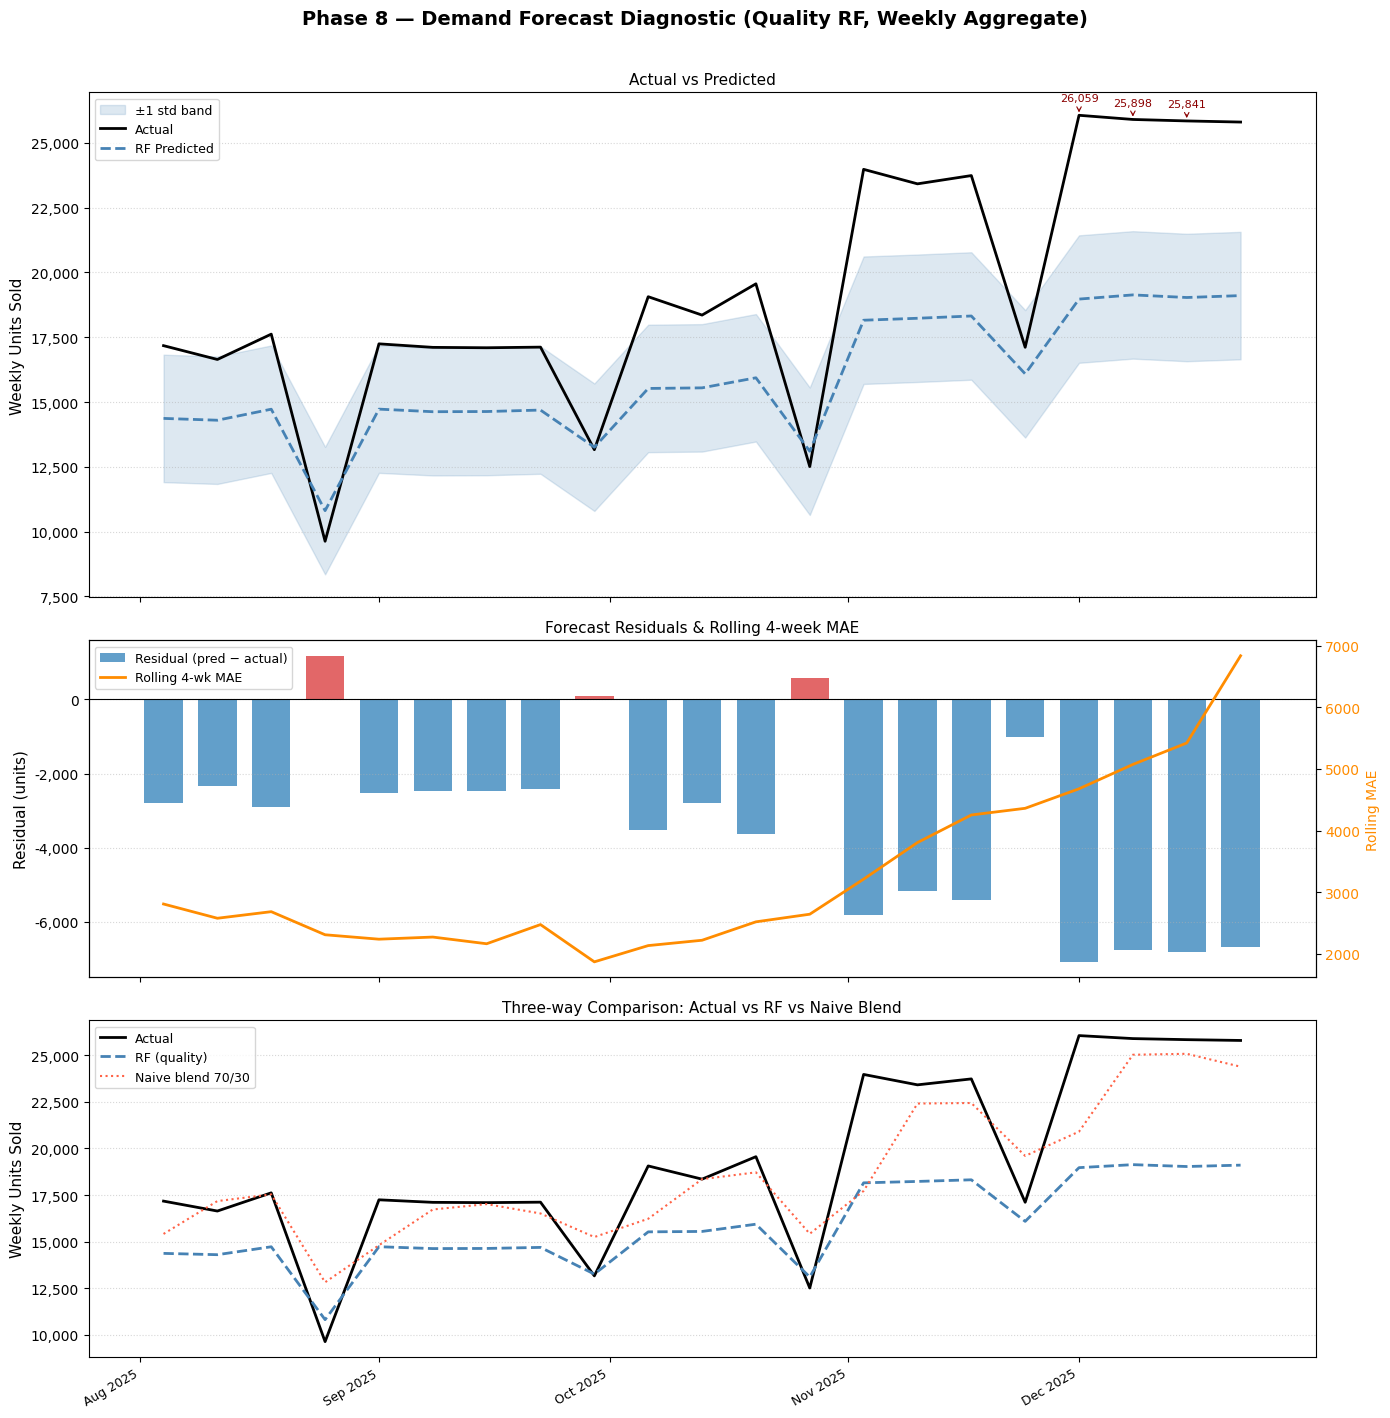

Chart saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase8_forecast_vs_actual.png
{'train_rows': 488985, 'test_rows': 150688, 'n_estimators': 500, 'training_min': 9.9}
Model comparison:


,model,mae,rmse,smape
0,rf_feature_model_quality,1.251206,1.849582,0.467654
1,naive_blend_70_30,1.490632,2.171708,0.514225
2,naive_lag_4w,1.598283,2.404485,0.539218
3,naive_lag_1w,1.636866,2.447264,0.544289


Top residuals:


,week_start_date,product_id,store_id_or_online,target_units,prediction,error,abs_error
215366,2025-12-22,P00879,ONLINE,25.0,3.821818,-21.178182,21.178182
376212,2025-08-04,P03265,ONLINE,23.0,2.803254,-20.196746,20.196746
51506,2025-09-01,P03986,S016,25.0,4.831301,-20.168699,20.168699
264474,2025-12-15,P04177,ONLINE,23.0,3.910878,-19.089122,19.089122
20046,2025-11-03,P04109,S008,23.0,4.182735,-18.817265,18.817265
356912,2025-12-01,P02816,ONLINE,22.0,3.199779,-18.800221,18.800221
336057,2025-11-17,P03357,ONLINE,21.0,3.739083,-17.260917,17.260917
330928,2025-12-15,P02564,S008,22.0,4.793231,-17.206769,17.206769
279655,2025-12-01,P00073,ONLINE,20.0,3.347999,-16.652001,16.652001
596098,2025-11-10,P00287,ONLINE,20.0,3.451654,-16.548346,16.548346


Artifacts written:
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase8_forecast_model_comparison.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase8_forecast_scored_sample_top500.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase8_forecast_weekly_actual_vs_pred.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase8_forecast_vs_actual.png


In [6]:

feature_cols = [c for c in approved_features if c not in ['week_start_date']]
X_train_full = train[feature_cols].copy()
X_test = test[feature_cols].copy()
y_train_full = train['target_units'].copy()
y_test = test['target_units'].copy()

# ── Quality-mode config: full data, deep forest — expect ~10-15 min runtime ──
X_train = X_train_full.copy()
y_train = y_train_full.copy()

num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ]
)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

import time
t0 = time.time()
pipe = Pipeline([('pre', pre), ('model', rf)])
pipe.fit(X_train, y_train)
train_time = time.time() - t0
print(f"Training time: {train_time/60:.1f} min  ({train_time:.0f}s)")

test['pred_rf'] = pipe.predict(X_test)

# ── Model comparison table ──
metric_rows = [
    {'model': 'naive_lag_1w',
     'mae': mean_absolute_error(y_test, test['pred_naive_1w']),
     'rmse': mean_squared_error(y_test, test['pred_naive_1w']) ** 0.5,
     'smape': smape(y_test, test['pred_naive_1w'])},
    {'model': 'naive_lag_4w',
     'mae': mean_absolute_error(y_test, test['pred_naive_4w']),
     'rmse': mean_squared_error(y_test, test['pred_naive_4w']) ** 0.5,
     'smape': smape(y_test, test['pred_naive_4w'])},
    {'model': 'naive_blend_70_30',
     'mae': mean_absolute_error(y_test, test['pred_naive_blend']),
     'rmse': mean_squared_error(y_test, test['pred_naive_blend']) ** 0.5,
     'smape': smape(y_test, test['pred_naive_blend'])},
    {'model': 'rf_feature_model_quality',
     'mae': mean_absolute_error(y_test, test['pred_rf']),
     'rmse': mean_squared_error(y_test, test['pred_rf']) ** 0.5,
     'smape': smape(y_test, test['pred_rf'])},
]

comparison = pd.DataFrame(metric_rows).sort_values('rmse').reset_index(drop=True)
best_model = comparison.iloc[0]['model']

# ── Weekly aggregation (test window) ──
weekly_plot = (
    test.groupby('week_start_date', as_index=False)
    .agg(
        actual_units=('target_units', 'sum'),
        pred_rf=('pred_rf', 'sum'),
        pred_naive=('pred_naive_blend', 'sum'),
    )
    .sort_values('week_start_date')
)
weekly_plot['week_start_date'] = pd.to_datetime(weekly_plot['week_start_date'])
weekly_plot['residual'] = weekly_plot['pred_rf'] - weekly_plot['actual_units']
weekly_plot['abs_error_rf'] = weekly_plot['residual'].abs()
weekly_plot['rolling_mae'] = weekly_plot['abs_error_rf'].rolling(4, min_periods=1).mean()
residual_std = weekly_plot['residual'].std()

# ── 3-panel time-series chart ──
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2, 2]})
fig.suptitle('Phase 8 — Demand Forecast Diagnostic (Quality RF, Weekly Aggregate)',
             fontsize=14, fontweight='bold', y=1.01)

dates = weekly_plot['week_start_date']

# ── Panel 1: Actual vs RF Predicted ──
ax1 = axes[0]
ax1.fill_between(dates,
                 weekly_plot['pred_rf'] - residual_std,
                 weekly_plot['pred_rf'] + residual_std,
                 alpha=0.18, color='steelblue', label='±1 std band')
ax1.plot(dates, weekly_plot['actual_units'], color='black', linewidth=2, label='Actual')
ax1.plot(dates, weekly_plot['pred_rf'], color='steelblue', linewidth=2,
         linestyle='--', label='RF Predicted')

# Annotate top-3 peak weeks in actual
top3_idx = weekly_plot['actual_units'].nlargest(3).index
for idx in top3_idx:
    row = weekly_plot.loc[idx]
    ax1.annotate(
        f"{row['actual_units']:,.0f}",
        xy=(row['week_start_date'], row['actual_units']),
        xytext=(0, 10), textcoords='offset points',
        fontsize=8, ha='center', color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8),
    )

ax1.set_ylabel('Weekly Units Sold', fontsize=11)
ax1.set_title('Actual vs Predicted', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# ── Panel 2: Residuals + Rolling MAE ──
ax2 = axes[1]
colors_res = ['#d62728' if r > 0 else '#1f77b4' for r in weekly_plot['residual']]
ax2.bar(dates, weekly_plot['residual'], color=colors_res, alpha=0.7,
        width=5, label='Residual (pred − actual)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2_r = ax2.twinx()
ax2_r.plot(dates, weekly_plot['rolling_mae'], color='darkorange', linewidth=2,
           label='Rolling 4-wk MAE')
ax2_r.set_ylabel('Rolling MAE', fontsize=10, color='darkorange')
ax2_r.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylabel('Residual (units)', fontsize=11)
ax2.set_title('Forecast Residuals & Rolling 4-week MAE', fontsize=11)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(axis='y', linestyle=':', alpha=0.5)

# ── Panel 3: Three-way comparison (Actual vs RF vs Naive blend) ──
ax3 = axes[2]
ax3.plot(dates, weekly_plot['actual_units'], color='black', linewidth=2,
         label='Actual')
ax3.plot(dates, weekly_plot['pred_rf'], color='steelblue', linewidth=2,
         linestyle='--', label='RF (quality)')
ax3.plot(dates, weekly_plot['pred_naive'], color='tomato', linewidth=1.5,
         linestyle=':', label='Naive blend 70/30')
ax3.set_ylabel('Weekly Units Sold', fontsize=11)
ax3.set_title('Three-way Comparison: Actual vs RF vs Naive Blend', fontsize=11)
ax3.legend(loc='upper left', fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.grid(axis='y', linestyle=':', alpha=0.5)

# Shared x-axis formatting
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)

plt.tight_layout()
chart_path = OUT / 'phase8_forecast_vs_actual.png'
plt.savefig(chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Chart saved → {chart_path}")

# ── Artifacts ──
residual_sample = test[['week_start_date', 'product_id', 'store_id_or_online',
                         'target_units', 'pred_rf']].copy()
residual_sample = residual_sample.rename(columns={'pred_rf': 'prediction'})
residual_sample['error'] = residual_sample['prediction'] - residual_sample['target_units']
residual_sample['abs_error'] = residual_sample['error'].abs()
residual_sample = residual_sample.sort_values('abs_error', ascending=False)

comparison_path = OUT / 'phase8_forecast_model_comparison.csv'
pred_path       = OUT / 'phase8_forecast_scored_sample_top500.csv'
weekly_path     = OUT / 'phase8_forecast_weekly_actual_vs_pred.csv'

comparison.to_csv(comparison_path, index=False)
residual_sample.head(500).to_csv(pred_path, index=False)
weekly_plot.to_csv(weekly_path, index=False)

print({'train_rows': len(X_train), 'test_rows': len(X_test),
       'n_estimators': 500, 'training_min': round(train_time/60, 1)})
print('Model comparison:')
display(comparison)
print('Top residuals:')
display(residual_sample.head(10))
print('Artifacts written:')
for p in [comparison_path, pred_path, weekly_path, chart_path]:
    print(' ', p)
